In [2]:
# Step 1: Load dataset and initial exploration
import pandas as pd

# Replace 'crop_yield_data.csv' with your dataset path
df = pd.read_csv('yield.csv')

# Basic info
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

# Sample rows
print("\nSample Data:")
print(df.head())

# Summary statistics
print("\nSummary Statistics:")
print(df.describe())

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")

# Check for missing values
missing = df.isnull().sum()
print("\nMissing values per column:")
print(missing)


Dataset Shape: (56717, 12)

Columns: ['Domain Code', 'Domain', 'Area Code', 'Area', 'Element Code', 'Element', 'Item Code', 'Item', 'Year Code', 'Year', 'Unit', 'Value']

Sample Data:
  Domain Code Domain  Area Code         Area  Element Code Element  Item Code  \
0          QC  Crops          2  Afghanistan          5419   Yield         56   
1          QC  Crops          2  Afghanistan          5419   Yield         56   
2          QC  Crops          2  Afghanistan          5419   Yield         56   
3          QC  Crops          2  Afghanistan          5419   Yield         56   
4          QC  Crops          2  Afghanistan          5419   Yield         56   

    Item  Year Code  Year   Unit  Value  
0  Maize       1961  1961  hg/ha  14000  
1  Maize       1962  1962  hg/ha  14000  
2  Maize       1963  1963  hg/ha  14260  
3  Maize       1964  1964  hg/ha  14257  
4  Maize       1965  1965  hg/ha  14400  

Summary Statistics:
          Area Code  Element Code     Item Code     Year

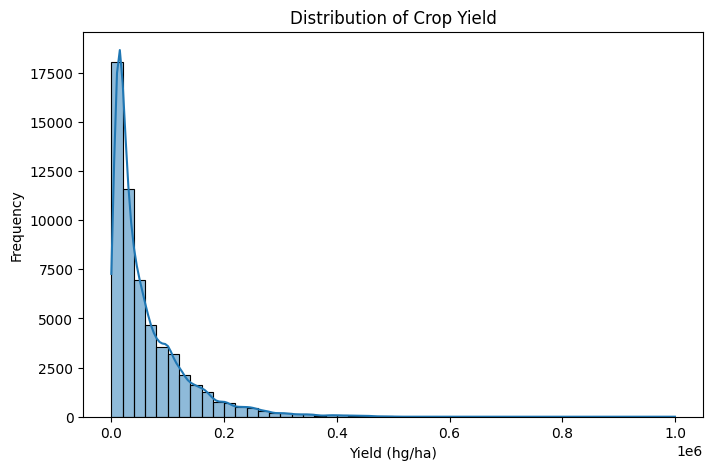

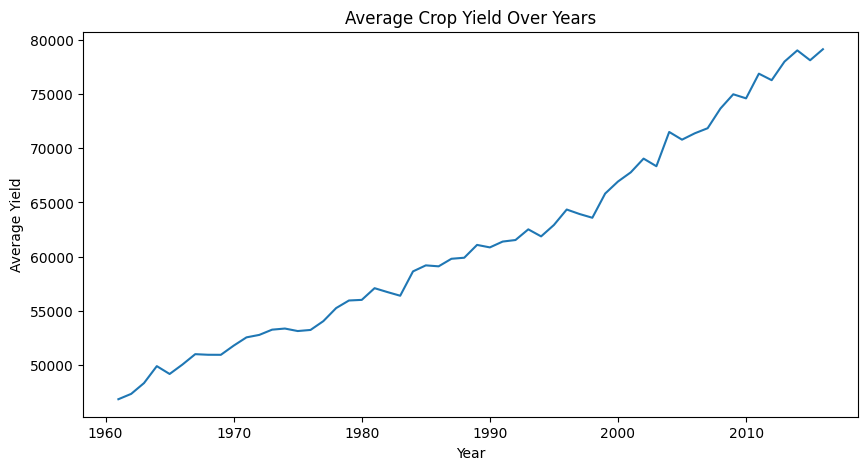

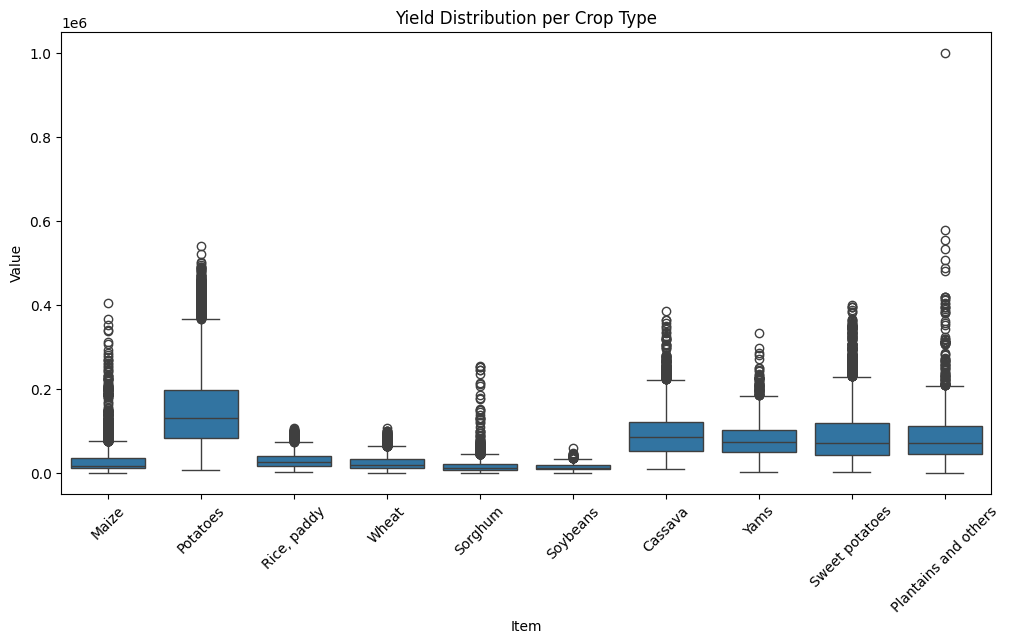

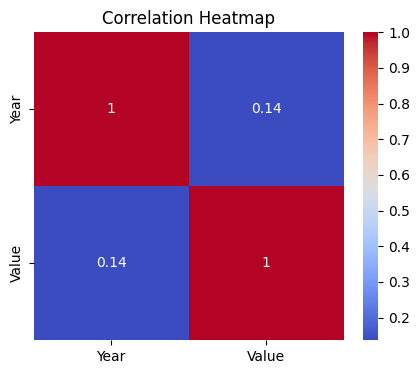

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot 1: Distribution of crop yield
plt.figure(figsize=(8,5))
sns.histplot(df['Value'], bins=50, kde=True)
plt.title('Distribution of Crop Yield')
plt.xlabel('Yield (hg/ha)')
plt.ylabel('Frequency')
plt.show()

# Plot 2: Yield over Years (average yield per year)
plt.figure(figsize=(10,5))
yearly_yield = df.groupby('Year')['Value'].mean()
sns.lineplot(x=yearly_yield.index, y=yearly_yield.values)
plt.title('Average Crop Yield Over Years')
plt.xlabel('Year')
plt.ylabel('Average Yield')
plt.show()

# Plot 3: Boxplot of Yield per Crop
plt.figure(figsize=(12,6))
sns.boxplot(x='Item', y='Value', data=df)
plt.xticks(rotation=45)
plt.title('Yield Distribution per Crop Type')
plt.show()


# Optional: Correlation heatmap (if you have numerical features)
numerical_cols = ['Year', 'Value']
plt.figure(figsize=(5,4))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


In [14]:
from sklearn.preprocessing import StandardScaler

# Scale features for ANN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Now predict with ANN
y_pred_ann = ann_model.predict(X_test_scaled).flatten()  # flatten to 1D array


355/355 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Select relevant columns
data = df[['Area', 'Item', 'Year', 'Value']].copy()

# Log-transform target variable to reduce skewness
data['Value_log'] = np.log1p(data['Value'])

# Aggregate features
# Average yield per crop
crop_avg = data.groupby('Item')['Value'].mean().to_dict()
data['Crop_Avg_Yield'] = data['Item'].map(crop_avg)

# Average yield per region
region_avg = data.groupby('Area')['Value'].mean().to_dict()
data['Region_Avg_Yield'] = data['Area'].map(region_avg)

# Optional: Polynomial features for Year
data['Year_Squared'] = data['Year'] ** 2

# One-hot encode categorical variables
data_encoded = pd.get_dummies(data, columns=['Area', 'Item'], drop_first=True)

# Separate features and target
X = data_encoded.drop(['Value', 'Value_log'], axis=1)
y = data_encoded['Value_log']  # Using log-transformed target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Random Forest
rf_model = RandomForestRegressor(n_estimators=50, max_depth=20, random_state=42)
rf_model.fit(X_train, y_train)

# ANN
ann_model = Sequential([
    Dense(128, input_dim=X_train.shape[1], activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])
ann_model.compile(optimizer='adam', loss='mse')
ann_model.fit(X_train_scaled, y_train, epochs=50, batch_size=64, validation_split=0.1)





Training set shape: (45373, 224)
Test set shape: (11344, 224)


D:\miniconda\envs\myenv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
639/639 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 3.0291 - val_loss: 0.2794
Epoch 2/50
639/639 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.2341 - val_loss: 0.1871
Epoch 3/50
639/639 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.1795 - val_loss: 0.1485
Epoch 4/50
639/639 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1588 - val_loss: 0.1359
Epoch 5/50
639/639 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.1475 - val_loss: 0.1172
Epoch 6/50
639/639 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1427 - val_loss: 0.1473
Epoch 7/50
639/639 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.1352 - val_loss: 0.1267
Epoch 8/50
639/639 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.1291 - val_loss: 0.1339
Epoch 9/50
639/639 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1261 - val_loss: 0.0999
Epoch 10/50
639/639 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.1161 - val_loss: 0.1053
Epoch 11/50
639/639 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1127 - val_loss: 0.0985
Epoch 12/50
639/639 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step

In [15]:
from sklearn.preprocessing import StandardScaler

# Scale features for ANN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Now predict with ANN
y_pred_ann = ann_model.predict(X_test_scaled).flatten()  # flatten to 1D array

y_pred_lr = lr_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)
y_pred_ann = ann_model.predict(X_test_scaled)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluate(y_true, y_pred):
    return {
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred)
    }

metrics_lr = evaluate(y_test, y_pred_lr)
metrics_rf = evaluate(y_test, y_pred_rf)
metrics_ann = evaluate(y_test, y_pred_ann)


355/355 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
355/355 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


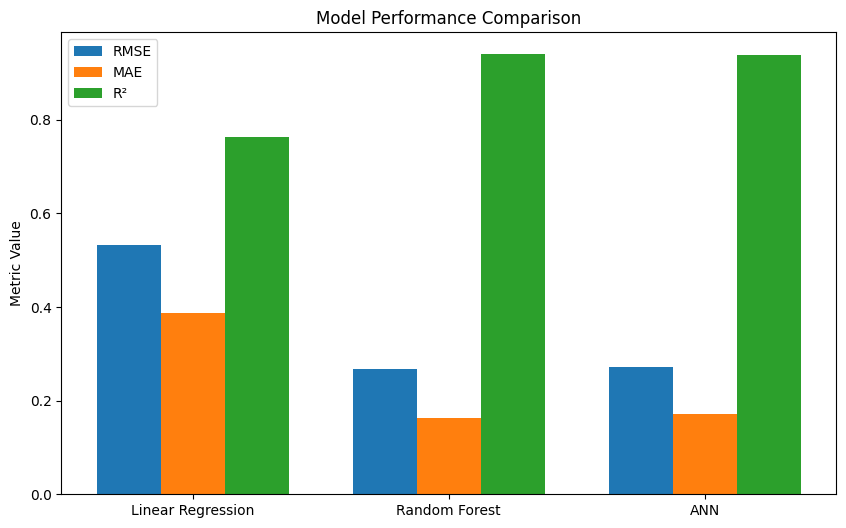

Linear Regression: RMSE=0.53, MAE=0.39, R²=0.764
Random Forest: RMSE=0.27, MAE=0.16, R²=0.940
ANN: RMSE=0.27, MAE=0.17, R²=0.938


In [16]:
import matplotlib.pyplot as plt

# Prepare data for plotting
models = ['Linear Regression', 'Random Forest', 'ANN']
rmse_vals = [metrics_lr['RMSE'], metrics_rf['RMSE'], metrics_ann['RMSE']]
mae_vals  = [metrics_lr['MAE'], metrics_rf['MAE'], metrics_ann['MAE']]
r2_vals   = [metrics_lr['R2'], metrics_rf['R2'], metrics_ann['R2']]

x = range(len(models))
width = 0.25

plt.figure(figsize=(10,6))
plt.bar([p - width for p in x], rmse_vals, width=width, label='RMSE')
plt.bar(x, mae_vals, width=width, label='MAE')
plt.bar([p + width for p in x], r2_vals, width=width, label='R²')

plt.xticks(x, models)
plt.ylabel('Metric Value')
plt.title('Model Performance Comparison')
plt.legend()
plt.show()

# Optional: print metrics nicely
for m, rmse, mae, r2 in zip(models, rmse_vals, mae_vals, r2_vals):
    print(f"{m}: RMSE={rmse:.2f}, MAE={mae:.2f}, R²={r2:.3f}")
